# MSCS 634 – Data Mining

## Project Deliverable 2: Regression Modeling and Performance Evaluation

**Student Name:** Priya Thapa  
**Instructor:** Dr. Satish Penmatsa

**Dataset:** Gym Members Exercise Dataset  

### Project Objective

The purpose of this deliverable is to develop and evaluate regression models that predict an outcome variable from the Gym Members Exercise Dataset. Feature-engineering techniques will be used to improve the available predictors, and multiple regression models will be trained and evaluated.

The models will be compared using appropriate regression evaluation metrics and visualizations to determine which model provides the most accurate predictions.

### Import necessary libraries

In [3]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools for splitting and preprocessing the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Import regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Import evaluation metrics for regression models
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display confirmation that the libraries were imported successfully
print("All required libraries were imported successfully.")

All required libraries were imported successfully.


### Uplaod the dataset

In [5]:
# Import the Google Colab file-upload utility
from google.colab import files

# Open the file-selection window
# Select the Gym Members Exercise Dataset CSV file from your computer
uploaded = files.upload()

Saving gym_members_exercise_tracking.csv to gym_members_exercise_tracking.csv


### Load the uploaded dataset

In [6]:
# Retrieve the name of the uploaded file
file_name = list(uploaded.keys())[0]

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_name)

# Display the uploaded filename
print("Dataset loaded successfully:", file_name)

# Display the first five rows of the dataset
df.head()

Dataset loaded successfully: gym_members_exercise_tracking.csv


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


### Preview dataset

In [9]:
# Display the first five records
# This provides a quick view of the values stored in each variable
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


### Inspect dataset structure

In [10]:
# Display information about the dataset
# This includes column names, data types, and non-null value counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

### Check for missing values

In [13]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64
Duplicates: 0


## Data Loading Summary

The Gym Members Exercise Dataset was uploaded and loaded into a Pandas DataFrame. This is the same dataset used during Project Deliverable 1.

Although the dataset was cleaned and explored in the previous deliverable, a brief inspection is performed again to ensure that the data loaded correctly and remains suitable for regression modeling. Repeating these basic validation steps also makes this notebook independent and reproducible.

## ***Feature Engineering***

Feature engineering is the process of creating new variables from existing dataset features. These new variables can help regression models recognize meaningful relationships that may not be immediately apparent from the original columns.

For this analysis, several features are created based on workout intensity, heart-rate behavior, body composition, hydration, and workout frequency. These engineered features may improve the model's ability to predict calories burned.

The target variable, `Calories_Burned`, is not used to create any new feature because doing so would cause data leakage.

### Data columns

In [22]:
# Display all column names in the dataset.
# This allows us to confirm that the required columns are available
# before creating the new engineered features.

print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


### Create a copy of the dataset

In [23]:
# Create a copy of the original dataset before performing feature engineering.
# This protects the original DataFrame and allows us to compare the original
# features with the engineered features later.

df_engineered = df.copy()

print("A copy of the dataset was created successfully.")
print("Original number of features:", df.shape[1])

A copy of the dataset was created successfully.
Original number of features: 15


### Engineered Feature 1: Heart Rate Increase

In [29]:
# Calculate how much the participant's average heart rate increased
# above their resting heart rate during the workout.
#
# A larger value generally indicates that the workout required more
# cardiovascular effort.

df_engineered["Heart_Rate_Increase"] = (
    df_engineered["Avg_BPM"] - df_engineered["Resting_BPM"]
)

### Engineered Feature 2: Heart Rate Intensity Ratio

In [30]:
# Calculate the participant's average workout heart rate as a proportion
# of their recorded maximum heart rate.
#
# This creates a normalized intensity measurement. It can be more useful
# than Avg_BPM alone because it considers each participant's maximum BPM.

df_engineered["Heart_Rate_Intensity"] = (
    df_engineered["Avg_BPM"] / df_engineered["Max_BPM"]
)

### Engineered Feature 3: Workout Load

In [31]:
# Create a workout-load feature by combining workout intensity
# with session duration.
#
# This feature represents the total cardiovascular effort across
# the entire workout session.

df_engineered["Workout_Load"] = (
    df_engineered["Heart_Rate_Intensity"]
    * df_engineered["Session_Duration (hours)"]
)

### Engineered Feature 4: Weekly Workout Time

In [32]:
# Estimate the participant's total workout time per week.
#
# This combines the duration of an individual workout with the number
# of days the participant exercises each week.

df_engineered["Weekly_Workout_Hours"] = (
    df_engineered["Session_Duration (hours)"]
    * df_engineered["Workout_Frequency (days/week)"]
)

### Engineered Feature 5: Lean Body Mass Estimate

In [33]:
# Estimate lean body mass using the participant's weight
# and body-fat percentage.
#
# Lean body mass represents the approximate weight of the body excluding fat.

df_engineered["Lean_Body_Mass"] = (
    df_engineered["Weight (kg)"]
    * (1 - df_engineered["Fat_Percentage"] / 100)
)

### Engineered Feature 6: Fat Mass Estimate

In [34]:
# Estimate the participant's body-fat mass in kilograms.
#
# This feature complements lean body mass and provides the model
# with another measurement of body composition.

df_engineered["Fat_Mass"] = (
    df_engineered["Weight (kg)"]
    * (df_engineered["Fat_Percentage"] / 100)
)

### Engineered Feature 7: Hydration per Kilogram

In [35]:
# Normalize water intake according to the participant's body weight.
#
# Two individuals may drink the same amount of water, but that amount
# may represent different hydration levels depending on their weight.

df_engineered["Water_Per_Kg"] = (
    df_engineered["Water_Intake (liters)"]
    / df_engineered["Weight (kg)"]
)

### Engineered Feature 8: BMI Category

In [36]:
# Convert the numerical BMI feature into general BMI categories.
#
# The category provides the model with a grouped representation
# of body composition in addition to the original continuous BMI value.

df_engineered["BMI_Category"] = pd.cut(
    df_engineered["BMI"],
    bins=[0, 18.5, 25, 30, float("inf")],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ],
    include_lowest=True
)

### Display the engineered features

In [37]:
# Create a list containing only the newly engineered feature names.
engineered_features = [
    "Heart_Rate_Increase",
    "Heart_Rate_Intensity",
    "Workout_Load",
    "Weekly_Workout_Hours",
    "Lean_Body_Mass",
    "Fat_Mass",
    "Water_Per_Kg",
    "BMI_Category"
]

# Display the first five rows of the newly created features.
# This allows us to verify that the calculations were completed correctly.

df_engineered[engineered_features].head()

,Heart_Rate_Increase,Heart_Rate_Intensity,Workout_Load,Weekly_Workout_Hours,Lean_Body_Mass,Fat_Mass,Water_Per_Kg,BMI_Category
0,97,0.872222,1.474056,6.76,77.1742,11.1258,0.039638,Obese
1,85,0.843575,1.096648,5.20,49.5089,25.3911,0.028037,Obese
2,68,0.730539,0.810898,4.44,45.3546,22.7454,0.033774,Normal
3,108,0.863158,0.509263,1.77,37.8784,15.3216,0.039474,Underweight
4,90,0.840426,0.537872,1.92,32.6388,13.4612,0.060738,Underweight


### Check for invalid values

In [38]:
# Import NumPy so that infinite values can be identified.
import numpy as np

# Check whether any engineered numerical features contain
# positive or negative infinity.
infinite_values = np.isinf(
    df_engineered[
        [
            "Heart_Rate_Intensity",
            "Workout_Load",
            "Water_Per_Kg"
        ]
    ]
).sum()

print("Infinite values in division-based features:")
print(infinite_values)


# Check whether any engineered features contain missing values.
print("\nMissing values in engineered features:")
print(df_engineered[engineered_features].isnull().sum())

Infinite values in division-based features:
Heart_Rate_Intensity    0
Workout_Load            0
Water_Per_Kg            0
dtype: int64

Missing values in engineered features:
Heart_Rate_Increase     0
Heart_Rate_Intensity    0
Workout_Load            0
Weekly_Workout_Hours    0
Lean_Body_Mass          0
Fat_Mass                0
Water_Per_Kg            0
BMI_Category            0
dtype: int64


### ***Feature Engineering Observations***

The feature-engineering process added variables that represent cardiovascular intensity, workout volume, body composition, and hydration.

- `Heart_Rate_Increase` measures the difference between average and resting heart rate.
- `Heart_Rate_Intensity` normalizes workout heart rate using the participant's maximum heart rate.
- `Workout_Load` combines workout intensity with session duration.
- `Weekly_Workout_Hours` estimates the participant's total weekly exercise volume.
- `Lean_Body_Mass` and `Fat_Mass` provide additional body-composition measurements.
- `Water_Per_Kg` normalizes water intake according to body weight.
- `BMI_Category` provides a categorical representation of the original numerical BMI feature.

These features were created without using the target variable, `Calories_Burned`, which prevents data leakage. Their usefulness will be evaluated later by comparing regression-model performance with appropriate evaluation metrics.

## ***Regression Model Development***

After completing feature engineering, the next step is to build regression models that predict the target variable, **Calories_Burned**.

Before training the models, the dataset is prepared by separating the predictor variables from the target variable. Categorical variables are converted into numerical representations using one-hot encoding so they can be used by the regression algorithms.

The dataset is then divided into training and testing sets. The training set is used to fit the regression models, while the testing set will later be used to evaluate how well the models generalize to unseen data.

Two regression models are implemented:

- Multiple Linear Regression
- Ridge Regression

The performance of these models will be evaluated and compared in the following section.

### Separate features and target

In [39]:
# Separate predictor variables (X) and target variable (y)

# The target variable is Calories_Burned because this is the
# value we want our regression models to predict.

y = df_engineered["Calories_Burned"]

# All remaining columns become predictor variables.
# The target variable is removed from the feature set.

X = df_engineered.drop("Calories_Burned", axis=1)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (973, 22)
Target vector shape: (973,)


### Encode Categorical Variables

In [41]:
# Convert categorical variables into numerical variables

# One-hot encoding creates binary columns for each category.
# The first category is dropped to avoid multicollinearity.

X = pd.get_dummies(
    X,
    drop_first=True
)

print("Shape after one-hot encoding:", X.shape)

Shape after one-hot encoding: (973, 26)


### Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

# 80% of the data is used to train the models.
# 20% is reserved for evaluating model performance.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 778
Testing samples: 195


### Feature Scaling

In [43]:
from sklearn.preprocessing import StandardScaler

# Standardize the numerical features

# Standardization transforms each feature so that it has
# a mean of 0 and a standard deviation of 1.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


### Multiple Linear Regression

In [44]:
from sklearn.linear_model import LinearRegression

# Build the Multiple Linear Regression model

# Create the Linear Regression model.

linear_model = LinearRegression()

# Train the model using the training data.

linear_model.fit(
    X_train_scaled,
    y_train
)

# Generate predictions on the testing data.
# These predictions will be evaluated later.

linear_predictions = linear_model.predict(
    X_test_scaled
)

print("Multiple Linear Regression model trained successfully.")

Multiple Linear Regression model trained successfully.


### Ridge Regression

In [45]:
from sklearn.linear_model import Ridge

# Build the Ridge Regression model

# Ridge Regression helps reduce overfitting by introducing
# a regularization penalty.

ridge_model = Ridge(alpha=1.0)

# Train the Ridge model.

ridge_model.fit(
    X_train_scaled,
    y_train
)

# Generate predictions for the testing data.

ridge_predictions = ridge_model.predict(
    X_test_scaled
)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


### Verify the models

In [46]:
# Display basic information about the trained models

print("Linear Regression Model")
print(linear_model)

print()

print("Ridge Regression Model")
print(ridge_model)

Linear Regression Model
LinearRegression()

Ridge Regression Model
Ridge()


## ***Model Evaluation***

The trained regression models are evaluated using the testing dataset, which contains observations that were not used during model training.

Four regression evaluation metrics are calculated:

- **R-squared (R²):** Measures the proportion of variation in calories burned that is explained by the model. A value closer to 1 indicates better performance.
- **Mean Squared Error (MSE):** Calculates the average squared difference between actual and predicted values. Lower values indicate better performance.
- **Root Mean Squared Error (RMSE):** Calculates the square root of MSE. It expresses the typical prediction error in the same unit as the target variable, calories burned.
- **Mean Absolute Error (MAE):** Calculates the average absolute difference between actual and predicted values. Lower values indicate more accurate predictions.

The same testing data is used to evaluate both models to ensure a fair comparison.

### Import Evaluation Metrics

In [47]:
# Import regression evaluation metrics

# r2_score calculates the R-squared value.
# mean_squared_error calculates the average squared prediction error.
# mean_absolute_error calculates the average absolute prediction error.

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# NumPy is used to calculate the square root of MSE
# when computing RMSE.
import numpy as np

### Evaluate Multiple Linear Regression

In [48]:
# Evaluate the Multiple Linear Regression model

# Calculate R-squared.
# A value closer to 1 indicates that the model explains
# more of the variation in calories burned.
linear_r2 = r2_score(
    y_test,
    linear_predictions
)

# Calculate Mean Squared Error.
# Lower MSE values indicate smaller prediction errors.
linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

# Calculate Root Mean Squared Error.
# RMSE is expressed in the same unit as Calories_Burned.
linear_rmse = np.sqrt(linear_mse)

# Calculate Mean Absolute Error.
# MAE represents the average absolute difference between
# the actual and predicted calories burned.
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

print("Multiple Linear Regression Evaluation")
print("-------------------------------------")
print(f"R-squared: {linear_r2:.4f}")
print(f"Mean Squared Error: {linear_mse:.4f}")
print(f"Root Mean Squared Error: {linear_rmse:.4f}")
print(f"Mean Absolute Error: {linear_mae:.4f}")

Multiple Linear Regression Evaluation
-------------------------------------
R-squared: 0.9854
Mean Squared Error: 1215.2923
Root Mean Squared Error: 34.8610
Mean Absolute Error: 26.8968


### Evaluate Ridge Regression

In [49]:
# Evaluate the Ridge Regression model

# Calculate R-squared for the Ridge Regression predictions.
ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

# Calculate Mean Squared Error.
ridge_mse = mean_squared_error(
    y_test,
    ridge_predictions
)

# Calculate Root Mean Squared Error.
ridge_rmse = np.sqrt(ridge_mse)

# Calculate Mean Absolute Error.
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

print("Ridge Regression Evaluation")
print("---------------------------")
print(f"R-squared: {ridge_r2:.4f}")
print(f"Mean Squared Error: {ridge_mse:.4f}")
print(f"Root Mean Squared Error: {ridge_rmse:.4f}")
print(f"Mean Absolute Error: {ridge_mae:.4f}")

Ridge Regression Evaluation
---------------------------
R-squared: 0.9854
Mean Squared Error: 1214.7987
Root Mean Squared Error: 34.8540
Mean Absolute Error: 26.8977


### Create a Model Comaprison Table

In [50]:
# Compare evaluation metrics across both regression models

# Create a DataFrame that stores the evaluation results
# for Multiple Linear Regression and Ridge Regression.
model_results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Ridge Regression"
    ],
    "R-squared": [
        linear_r2,
        ridge_r2
    ],
    "MSE": [
        linear_mse,
        ridge_mse
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse
    ],
    "MAE": [
        linear_mae,
        ridge_mae
    ]
})

# Round the numerical values to four decimal places
# to make the comparison table easier to read.
model_results = model_results.round(4)

# Display the completed model comparison table.
model_results

,Model,R-squared,MSE,RMSE,MAE
0,Multiple Linear Regression,0.9854,1215.2923,34.861,26.8968
1,Ridge Regression,0.9854,1214.7987,34.854,26.8977


### Identify the Best Model

In [51]:
# Identify the model with the highest R-squared value

# Locate the row containing the highest R-squared value.
best_r2_index = model_results["R-squared"].idxmax()

# Retrieve the name and R-squared value of the best model.
best_r2_model = model_results.loc[best_r2_index, "Model"]
best_r2_value = model_results.loc[best_r2_index, "R-squared"]

print("Best model based on R-squared:")
print(f"{best_r2_model} with an R-squared of {best_r2_value:.4f}")

Best model based on R-squared:
Multiple Linear Regression with an R-squared of 0.9854


In [53]:
# Identify the model with the lowest RMSE

# Lower RMSE indicates that the model's predictions are
# generally closer to the actual calories-burned values.
best_rmse_index = model_results["RMSE"].idxmin()

best_rmse_model = model_results.loc[best_rmse_index, "Model"]
best_rmse_value = model_results.loc[best_rmse_index, "RMSE"]

print("Best model based on RMSE:")
print(f"{best_rmse_model} with an RMSE of {best_rmse_value:.4f}")

Best model based on RMSE:
Ridge Regression with an RMSE of 34.8540


### Display Overall Evaluation Summary

In [54]:
# Display a concise model evaluation summary

print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)

for index, row in model_results.iterrows():
    print(f"\nModel: {row['Model']}")
    print(f"R-squared: {row['R-squared']:.4f}")
    print(f"MSE:       {row['MSE']:.4f}")
    print(f"RMSE:      {row['RMSE']:.4f}")
    print(f"MAE:       {row['MAE']:.4f}")

print("\n" + "=" * 60)
print(f"Highest R-squared: {best_r2_model}")
print(f"Lowest RMSE: {best_rmse_model}")

MODEL PERFORMANCE SUMMARY

Model: Multiple Linear Regression
R-squared: 0.9854
MSE:       1215.2923
RMSE:      34.8610
MAE:       26.8968

Model: Ridge Regression
R-squared: 0.9854
MSE:       1214.7987
RMSE:      34.8540
MAE:       26.8977

Highest R-squared: Multiple Linear Regression
Lowest RMSE: Ridge Regression


### ***Model Evaluation Interpretation***

Both regression models performed very well when predicting `Calories_Burned`.

The **Multiple Linear Regression** model achieved an R-squared value of **0.9854**, while the **Ridge Regression** model also achieved an R-squared value of **0.9854**. This means that both models explained approximately **98.54% of the variation in calories burned**. The very high R-squared values indicate that the selected original and engineered features were strongly related to the target variable.

The Multiple Linear Regression model produced an MSE of **1215.2923**, an RMSE of **34.8610**, and an MAE of **26.8968**. The Ridge Regression model produced an MSE of **1214.7987**, an RMSE of **34.8540**, and an MAE of **26.8977**.

The results are extremely similar. Multiple Linear Regression had a slightly higher R-squared value before rounding and a slightly lower MAE. Ridge Regression had a slightly lower MSE and RMSE. However, these differences are very small and do not represent a meaningful difference in predictive performance.

Based on RMSE, Ridge Regression performed slightly better because its predictions had a marginally lower overall error. Ridge Regression also includes regularization, which helps control large model coefficients and may improve stability when predictors are correlated. Overall, both models demonstrated excellent performance, but Ridge Regression can be considered the preferred model because it achieved the lowest MSE and RMSE while maintaining nearly identical explanatory power.

## ***Cross-Validation***

Cross-validation is used to assess how well a model is likely to perform on unseen data.

In this analysis, 5-fold cross-validation is applied. The dataset is divided into five subsets, or folds. During each round, four folds are used for training and the remaining fold is used for validation. This process is repeated until every fold has been used as the validation set once.

The following cross-validation metrics are calculated:

- Mean R-squared
- Standard deviation of R-squared
- Mean RMSE
- Standard deviation of RMSE

Higher mean R-squared values indicate stronger predictive performance, while lower mean RMSE values indicate smaller prediction errors. A smaller standard deviation suggests that the model performs consistently across different subsets of the data.

### Import Cross Validation Tools

In [56]:
# Import tools needed for cross-validation

# KFold controls how the dataset is divided into folds.
# cross_validate evaluates multiple scoring metrics during cross-validation.
# Pipeline allows preprocessing and model training to occur safely
# within each fold, which prevents data leakage.

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

import numpy as np
import pandas as pd

### Create Cross Validation Strategy

In [57]:
# Create a 5-fold cross-validation strategy

# n_splits=5 divides the dataset into five folds.
# shuffle=True randomizes the observations before creating the folds.
# random_state=42 ensures that the same folds are created
# every time the notebook is run.

cv_strategy = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold cross-validation strategy created successfully.")

5-fold cross-validation strategy created successfully.


### Create Pipelines for Both Models

In [58]:
# Create regression pipelines

# The pipeline standardizes the features inside each training fold.
# This prevents information from the validation fold from influencing
# the scaling process.

linear_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

ridge_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

print("Cross-validation pipelines created successfully.")

Cross-validation pipelines created successfully.


### Define the Cross Validatin Metrics

In [60]:
# Define the evaluation metrics used during cross-validation

# R-squared is returned normally.
# Scikit-learn returns RMSE as a negative value because its
# model-selection tools assume that larger scores are better.
# The values will be converted back to positive RMSE later.

scoring_metrics = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error"
}

### Perform Cross Validation for Multiple Linear Regression

In [61]:
# Perform 5-fold cross-validation for Linear Regression

linear_cv_scores = cross_validate(
    estimator=linear_cv_pipeline,
    X=X,
    y=y,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=False
)

# Convert the negative RMSE values returned by scikit-learn
# into positive values so they are easier to interpret.
linear_cv_rmse = -linear_cv_scores["test_rmse"]

# Store the R-squared values from all five folds.
linear_cv_r2 = linear_cv_scores["test_r2"]

print("Multiple Linear Regression Cross-Validation Results")
print("R-squared scores:", np.round(linear_cv_r2, 4))
print("RMSE scores:", np.round(linear_cv_rmse, 4))

Multiple Linear Regression Cross-Validation Results
R-squared scores: [0.9854 0.9853 0.9838 0.9852 0.9818]
RMSE scores: [34.861  31.858  34.3284 33.9747 35.1996]


### Perform Cross Validation for Multiple Ridge Regression

In [62]:
# Perform 5-fold cross-validation for Ridge Regression

ridge_cv_scores = cross_validate(
    estimator=ridge_cv_pipeline,
    X=X,
    y=y,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=False
)

# Convert negative RMSE scores into positive values.
ridge_cv_rmse = -ridge_cv_scores["test_rmse"]

# Store the R-squared scores from all five folds.
ridge_cv_r2 = ridge_cv_scores["test_r2"]

print("Ridge Regression Cross-Validation Results")
print("R-squared scores:", np.round(ridge_cv_r2, 4))
print("RMSE scores:", np.round(ridge_cv_rmse, 4))

Ridge Regression Cross-Validation Results
R-squared scores: [0.9854 0.9853 0.9838 0.9852 0.9818]
RMSE scores: [34.854  31.8871 34.3451 34.0159 35.1865]


### Create Cross Validation Comparison Table

In [63]:
# Summarize cross-validation performance across both models

cv_results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Ridge Regression"
    ],
    "Mean CV R-squared": [
        linear_cv_r2.mean(),
        ridge_cv_r2.mean()
    ],
    "R-squared Standard Deviation": [
        linear_cv_r2.std(),
        ridge_cv_r2.std()
    ],
    "Mean CV RMSE": [
        linear_cv_rmse.mean(),
        ridge_cv_rmse.mean()
    ],
    "RMSE Standard Deviation": [
        linear_cv_rmse.std(),
        ridge_cv_rmse.std()
    ]
})

# Round the values to four decimal places
# to make the table easier to read.
cv_results = cv_results.round(4)

# Display the cross-validation comparison table.
cv_results

,Model,Mean CV R-squared,R-squared Standard Deviation,Mean CV RMSE,RMSE Standard Deviation
0,Multiple Linear Regression,0.9843,0.0014,34.0443,1.1720
1,Ridge Regression,0.9843,0.0014,34.0577,1.1579


### Display an Overall Cross Validation Summary

In [64]:
# Display a concise cross-validation summary

print("CROSS-VALIDATION PERFORMANCE SUMMARY")
print("=" * 70)

for index, row in cv_results.iterrows():
    print(f"\nModel: {row['Model']}")
    print(f"Mean CV R-squared:             {row['Mean CV R-squared']:.4f}")
    print(f"R-squared Standard Deviation:  {row['R-squared Standard Deviation']:.4f}")
    print(f"Mean CV RMSE:                  {row['Mean CV RMSE']:.4f}")
    print(f"RMSE Standard Deviation:       {row['RMSE Standard Deviation']:.4f}")

print("\n" + "=" * 70)

CROSS-VALIDATION PERFORMANCE SUMMARY

Model: Multiple Linear Regression
Mean CV R-squared:             0.9843
R-squared Standard Deviation:  0.0014
Mean CV RMSE:                  34.0443
RMSE Standard Deviation:       1.1720

Model: Ridge Regression
Mean CV R-squared:             0.9843
R-squared Standard Deviation:  0.0014
Mean CV RMSE:                  34.0577
RMSE Standard Deviation:       1.1579



### Identify the best Cross Validation Model

In [65]:
# Identify the best-performing model based on cross-validation

# Higher mean R-squared indicates better explanatory performance.
best_cv_r2_index = cv_results["Mean CV R-squared"].idxmax()
best_cv_r2_model = cv_results.loc[best_cv_r2_index, "Model"]

# Lower mean RMSE indicates smaller average prediction errors.
best_cv_rmse_index = cv_results["Mean CV RMSE"].idxmin()
best_cv_rmse_model = cv_results.loc[best_cv_rmse_index, "Model"]

print("Best model based on mean cross-validation R-squared:")
print(best_cv_r2_model)

print("\nBest model based on mean cross-validation RMSE:")
print(best_cv_rmse_model)

Best model based on mean cross-validation R-squared:
Multiple Linear Regression

Best model based on mean cross-validation RMSE:
Multiple Linear Regression


### ***Cross-Validation Interpretation***

Five-fold cross-validation was performed to evaluate how well the regression models generalize to unseen data by repeatedly training and validating the models on different subsets of the dataset.

The **Multiple Linear Regression** model achieved a mean cross-validation **R-squared of 0.9843** with a standard deviation of **0.0014**, indicating that the model consistently explained approximately **98.43% of the variation in calories burned** across all validation folds. The model also produced a mean **RMSE of 34.0443**, showing a low average prediction error.

The **Ridge Regression** model produced nearly identical results, with a mean cross-validation **R-squared of 0.9843** and the same **R-squared standard deviation of 0.0014**. Its mean **RMSE was 34.0577**, which is only slightly higher than that of the Multiple Linear Regression model. The RMSE standard deviation of **1.1579** also indicates consistent performance across the validation folds.

Overall, both models demonstrated excellent generalization ability, as evidenced by their high mean R-squared values and low standard deviations. The cross-validation results are also very similar to the earlier test-set evaluation, suggesting that neither model is overfitting the training data.

Among the two models, **Multiple Linear Regression** performed marginally better during cross-validation because it achieved the lowest mean RMSE while maintaining the same mean R-squared as Ridge Regression. However, the performance difference between the two models is extremely small, indicating that both regression approaches are highly effective for predicting calories burned using this dataset.

# ***Visualizations***

Visualizations are used to compare the performance of the Multiple Linear Regression and Ridge Regression models and to examine the quality of their predictions.

The following visualizations are included:

1. Holdout-test R-squared comparison
2. Holdout-test RMSE comparison
3. Actual versus predicted values for Multiple Linear Regression
4. Actual versus predicted values for Ridge Regression
5. Residual distribution for Multiple Linear Regression
6. Residual distribution for Ridge Regression
7. Cross-validation R-squared comparison
8. Cross-validation RMSE comparison

Together, these visualizations show both the numerical performance of the models and the patterns in their prediction errors.

### Holdout-Test R-Squared Comparison

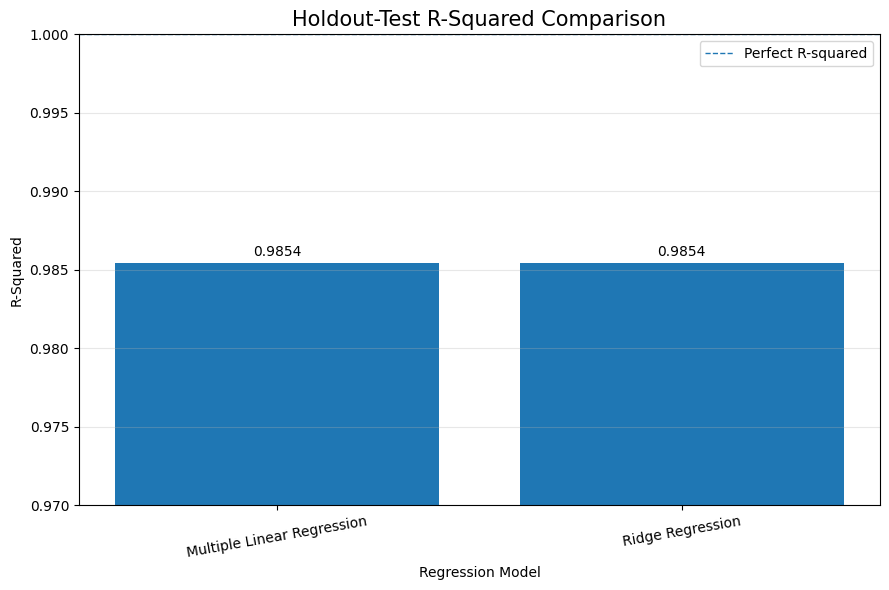

In [66]:
# Visualize the holdout-test R-squared values

import matplotlib.pyplot as plt

# Create a bar chart using the R-squared values stored
# in the model_results DataFrame.
plt.figure(figsize=(9, 6))

bars = plt.bar(
    model_results["Model"],
    model_results["R-squared"]
)

# Add a descriptive chart title and axis labels.
plt.title(
    "Holdout-Test R-Squared Comparison",
    fontsize=15
)
plt.xlabel("Regression Model")
plt.ylabel("R-Squared")

# Because both R-squared values are close to 1,
# use a focused y-axis range to make small differences visible.
plt.ylim(0.97, 1.00)

# Add a horizontal reference line at R-squared = 1,
# which represents perfect explanatory performance.
plt.axhline(
    y=1.0,
    linestyle="--",
    linewidth=1,
    label="Perfect R-squared"
)

# Display the exact R-squared value above each bar.
for bar, value in zip(bars, model_results["R-squared"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0003,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

# Rotate model names slightly so they remain readable.
plt.xticks(rotation=10)

# Display a light grid to make comparison easier.
plt.grid(axis="y", alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()

### R-Squared Comparison Interpretation

Both Multiple Linear Regression and Ridge Regression achieved an R-squared value of approximately **0.9854** on the testing dataset. This means that both models explained approximately **98.54% of the variation in calories burned**.

The nearly identical bar heights demonstrate that Ridge regularization did not produce a meaningful improvement in explanatory performance. Both models captured the relationship between the predictor variables and calories burned extremely well.

### Holdout-Test RMSE Comparison

In [ ]:
# Visualize the holdout-test RMSE values

plt.figure(figsize=(9, 6))

bars = plt.bar(
    model_results["Model"],
    model_results["RMSE"]
)

plt.title(
    "Holdout-Test RMSE Comparison",
    fontsize=15
)
plt.xlabel("Regression Model")
plt.ylabel("Root Mean Squared Error")

# Begin the y-axis at zero so that the bar heights
# accurately represent the size of the errors.
plt.ylim(
    0,
    model_results["RMSE"].max() * 1.15
)

# Add the exact RMSE value above each bar.
for bar, value in zip(bars, model_results["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Holdout-Test RMSE Interpretation

The RMSE values for the two models were nearly identical. Multiple Linear Regression achieved an RMSE of **34.8610**, while Ridge Regression achieved an RMSE of **34.8540**.

Because lower RMSE values indicate smaller prediction errors, Ridge Regression performed slightly better on the holdout testing dataset. However, the difference was only approximately **0.007 calories**, which is too small to represent a meaningful practical improvement.

The chart confirms that both models produced predictions with approximately the same level of accuracy.

### Actual vs. Predicted — Multiple Linear Regression

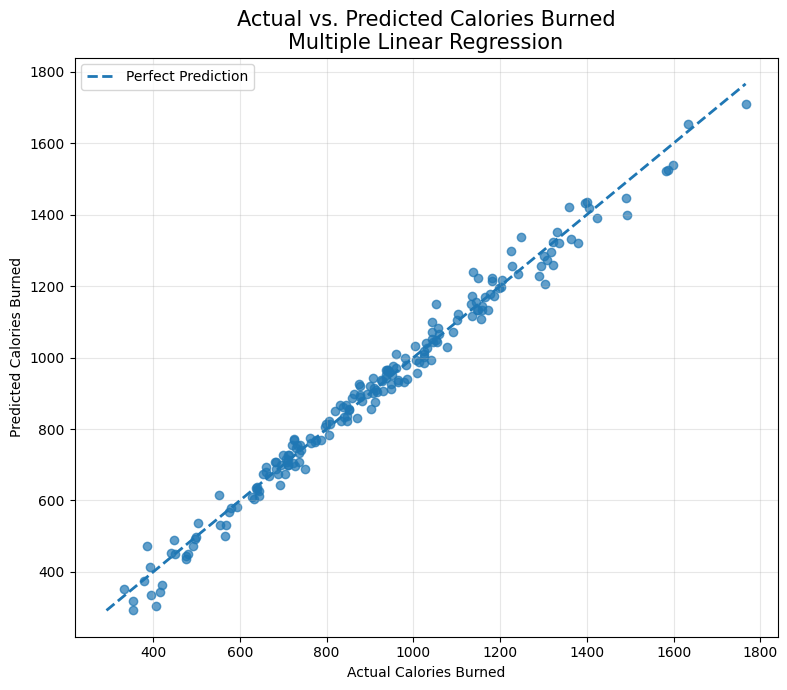

In [67]:
# Plot actual versus predicted values for Linear Regression

plt.figure(figsize=(8, 7))

# Plot each testing observation using its actual and predicted value.
plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.7
)

# Determine the minimum and maximum values needed
# to draw the perfect-prediction reference line.
linear_min_value = min(
    y_test.min(),
    linear_predictions.min()
)

linear_max_value = max(
    y_test.max(),
    linear_predictions.max()
)

# Draw a diagonal reference line.
# A prediction located directly on this line is perfectly accurate.
plt.plot(
    [linear_min_value, linear_max_value],
    [linear_min_value, linear_max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs. Predicted Calories Burned\nMultiple Linear Regression",
    fontsize=15
)
plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Multiple Linear Regression: Actual vs. Predicted Interpretation

The actual-versus-predicted scatter plot shows that most observations are located very close to the diagonal reference line. This indicates that the Multiple Linear Regression model generated predictions that closely matched the actual calories-burned values.

The points follow a strong linear pattern across both lower and higher calorie values. There is no obvious region in which the model consistently overpredicts or underpredicts the target. The close alignment supports the model's high R-squared value of **0.9854** and relatively low RMSE of **34.8610**.

Although some observations fall farther from the reference line, these errors are limited compared with the overall range of calories burned.

### Actual vs. Predicted — Ridge Regression

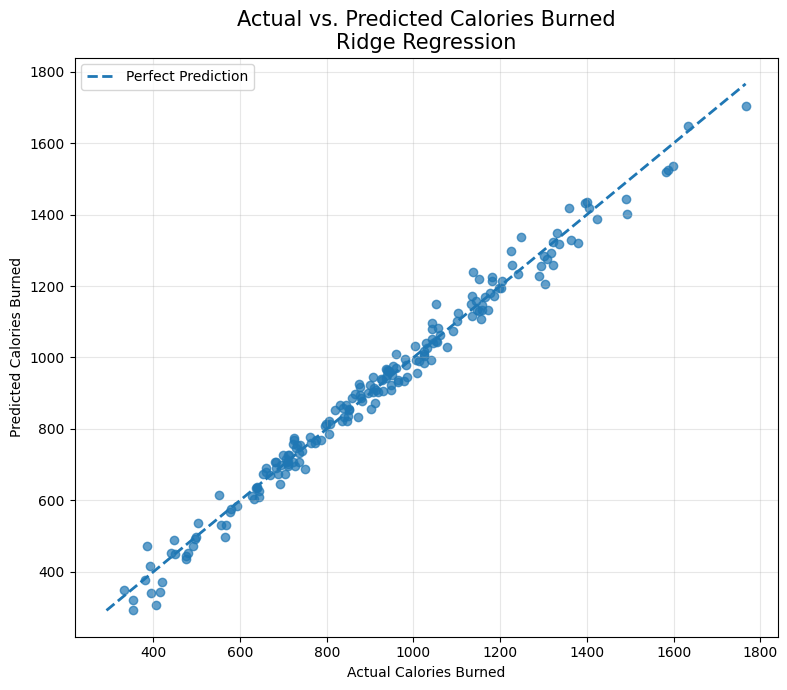

In [68]:
# Plot actual versus predicted values for Ridge Regression

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    ridge_predictions,
    alpha=0.7
)

# Determine the minimum and maximum values needed
# for the perfect-prediction reference line.
ridge_min_value = min(
    y_test.min(),
    ridge_predictions.min()
)

ridge_max_value = max(
    y_test.max(),
    ridge_predictions.max()
)

plt.plot(
    [ridge_min_value, ridge_max_value],
    [ridge_min_value, ridge_max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs. Predicted Calories Burned\nRidge Regression",
    fontsize=15
)
plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Ridge Regression: Actual vs. Predicted Interpretation

The Ridge Regression predictions also appear close to the perfect-prediction reference line. This indicates that Ridge Regression accurately predicted calories burned across the testing dataset.

The pattern is almost identical to the Multiple Linear Regression plot, which is consistent with the nearly equal R-squared, RMSE, and MAE values produced by the two models.

Ridge Regression slightly reduced the holdout-test RMSE, but the visual difference between the two prediction plots is minimal. This suggests that regularization did not substantially change the model's predictive behavior.

### Residual Plot — Multiple Linear Regression

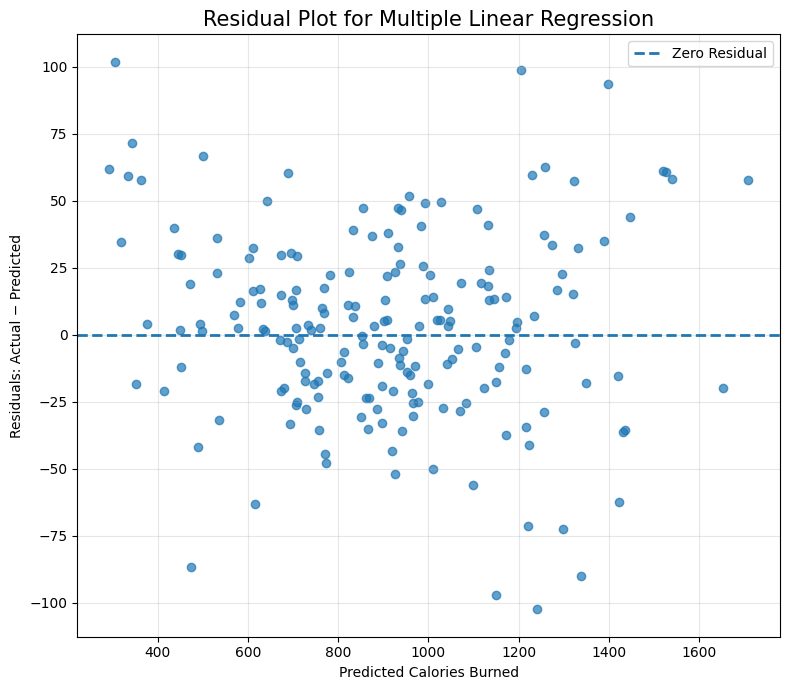

In [69]:
# Calculate and visualize Linear Regression residuals

# Calculate the difference between the actual and predicted values.
linear_residuals = y_test - linear_predictions

plt.figure(figsize=(8, 7))

# Plot predicted values against their residuals.
plt.scatter(
    linear_predictions,
    linear_residuals,
    alpha=0.7
)

# Draw a horizontal line at zero.
# Points above zero represent underprediction.
# Points below zero represent overprediction.
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2,
    label="Zero Residual"
)

plt.title(
    "Residual Plot for Multiple Linear Regression",
    fontsize=15
)
plt.xlabel("Predicted Calories Burned")
plt.ylabel("Residuals: Actual − Predicted")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Multiple Linear Regression Residual Interpretation

The residuals are distributed around the horizontal zero line, indicating that the model does not consistently overpredict or underpredict calories burned.

There is no strong curved pattern in the residual plot, which supports the suitability of a linear regression model for this dataset. The residual spread appears relatively consistent across the range of predicted calorie values.

A small number of observations have larger residuals, but the overall pattern appears random. This provides additional evidence that the Multiple Linear Regression model fits the data well.

### Residual Plot — Ridge Regression

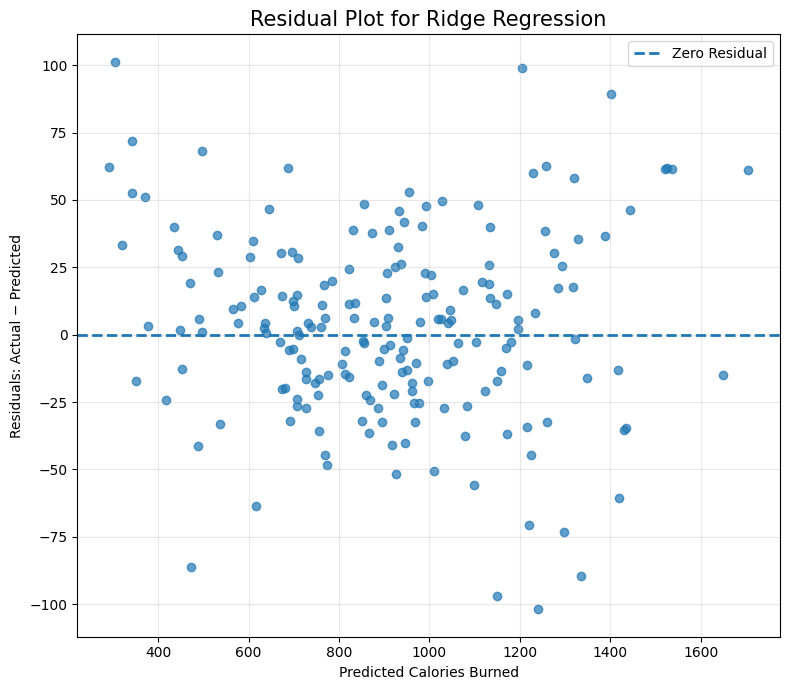

In [70]:
# Calculate and visualize Ridge Regression residuals

ridge_residuals = y_test - ridge_predictions

plt.figure(figsize=(8, 7))

plt.scatter(
    ridge_predictions,
    ridge_residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2,
    label="Zero Residual"
)

plt.title(
    "Residual Plot for Ridge Regression",
    fontsize=15
)
plt.xlabel("Predicted Calories Burned")
plt.ylabel("Residuals: Actual − Predicted")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Ridge Regression Residual Interpretation

The Ridge Regression residuals are also centered around zero and do not display a strong systematic pattern. This indicates that Ridge Regression does not consistently predict values that are too high or too low.

The residual pattern closely resembles the pattern observed for Multiple Linear Regression. This is expected because the two models produced nearly identical evaluation results.

The absence of a clear residual pattern supports the conclusion that Ridge Regression provides an appropriate fit for predicting calories burned.

### Residual Distribution Comparison

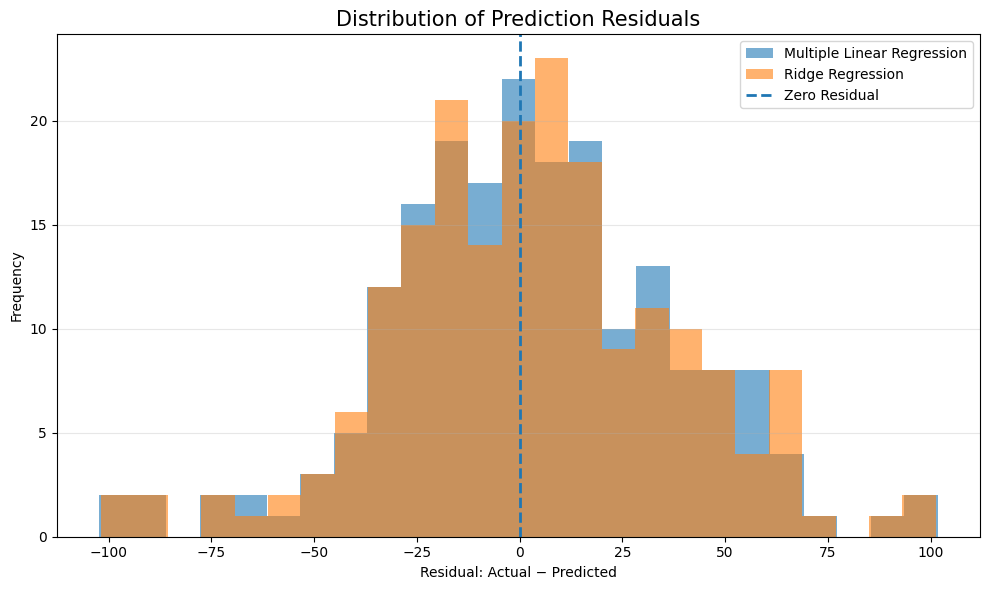

In [71]:
# Compare the distributions of residuals from both models

plt.figure(figsize=(10, 6))

# Plot the residual distribution for Multiple Linear Regression.
plt.hist(
    linear_residuals,
    bins=25,
    alpha=0.6,
    label="Multiple Linear Regression"
)

# Plot the residual distribution for Ridge Regression
# on the same axes for direct comparison.
plt.hist(
    ridge_residuals,
    bins=25,
    alpha=0.6,
    label="Ridge Regression"
)

# Add a reference line at zero residual.
plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2,
    label="Zero Residual"
)

plt.title(
    "Distribution of Prediction Residuals",
    fontsize=15
)
plt.xlabel("Residual: Actual − Predicted")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Residual Distribution Interpretation

The residual distributions for Multiple Linear Regression and Ridge Regression overlap almost completely. This further demonstrates that the two models produced nearly identical predictions.

Both residual distributions are centered near zero, indicating that the models do not show a strong overall tendency to overpredict or underpredict calories burned.

The similarity of the distributions supports the numerical evaluation results, which showed only very small differences between the two models.

### Mean Cross-Validation R-Squared

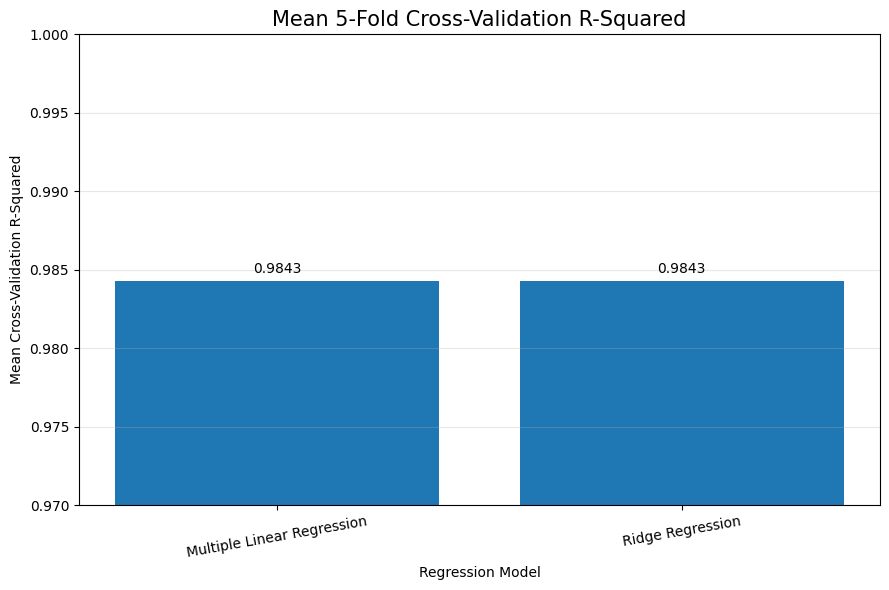

In [72]:
# Visualize mean cross-validation R-squared values

plt.figure(figsize=(9, 6))

bars = plt.bar(
    cv_results["Model"],
    cv_results["Mean CV R-squared"]
)

plt.title(
    "Mean 5-Fold Cross-Validation R-Squared",
    fontsize=15
)
plt.xlabel("Regression Model")
plt.ylabel("Mean Cross-Validation R-Squared")

# Use a focused range because both scores are close to 1.
plt.ylim(0.97, 1.00)

# Display the exact value above each bar.
for bar, value in zip(
    bars,
    cv_results["Mean CV R-squared"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0003,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-Validation R-Squared Interpretation

Both models achieved a mean cross-validation R-squared of **0.9843**. This means that, on average, each model explained approximately **98.43% of the variation in calories burned** across the five validation folds.

The equal bar heights show that neither model had an advantage in average cross-validation explanatory performance. The strong cross-validation results also confirm that the high testing performance was not limited to one favorable train-test split.

### Mean Cross-Validation RMSE

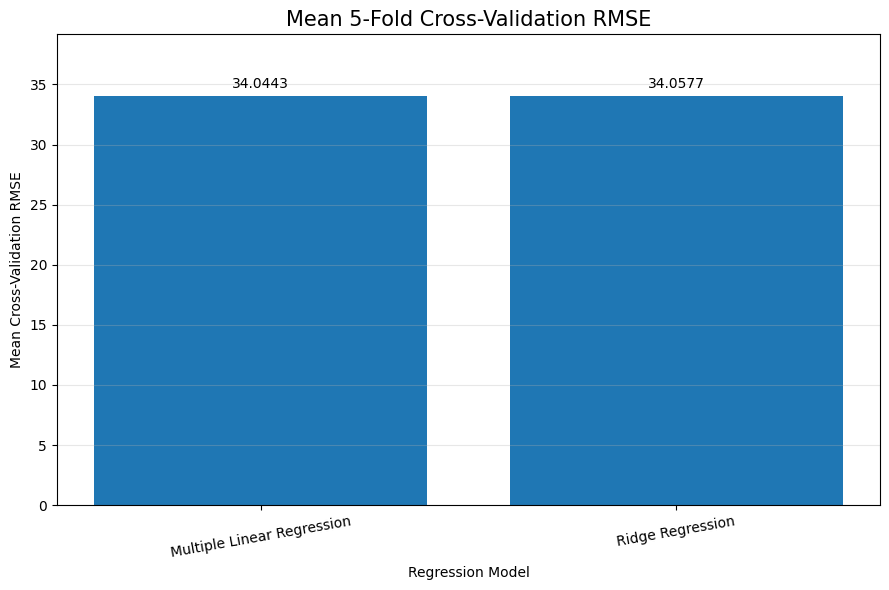

In [73]:
# Visualize mean cross-validation RMSE values

plt.figure(figsize=(9, 6))

bars = plt.bar(
    cv_results["Model"],
    cv_results["Mean CV RMSE"]
)

plt.title(
    "Mean 5-Fold Cross-Validation RMSE",
    fontsize=15
)
plt.xlabel("Regression Model")
plt.ylabel("Mean Cross-Validation RMSE")

plt.ylim(
    0,
    cv_results["Mean CV RMSE"].max() * 1.15
)

# Display the exact RMSE value above each bar.
for bar, value in zip(
    bars,
    cv_results["Mean CV RMSE"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-Validation RMSE Interpretation

Multiple Linear Regression achieved a mean cross-validation RMSE of **34.0443**, while Ridge Regression achieved a mean cross-validation RMSE of **34.0577**.

Because lower RMSE is better, Multiple Linear Regression performed marginally better across the five validation folds. However, the difference was only approximately **0.0134 calories**, which is negligible.

The visualization confirms that both models generalized to unseen data with nearly identical prediction accuracy.

### RMSE Consistency Across Cross-Validation Folds

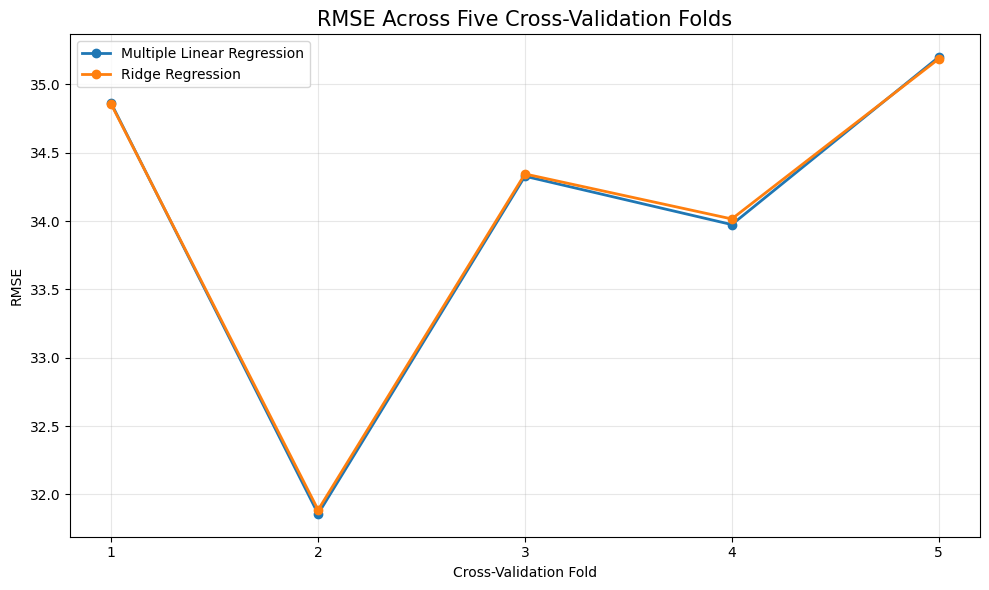

In [74]:
# Compare RMSE across all five cross-validation folds

# Create fold labels from 1 through 5.
fold_numbers = np.arange(
    1,
    len(linear_cv_rmse) + 1
)

plt.figure(figsize=(10, 6))

# Plot the RMSE from each fold for Multiple Linear Regression.
plt.plot(
    fold_numbers,
    linear_cv_rmse,
    marker="o",
    linewidth=2,
    label="Multiple Linear Regression"
)

# Plot the RMSE from each fold for Ridge Regression.
plt.plot(
    fold_numbers,
    ridge_cv_rmse,
    marker="o",
    linewidth=2,
    label="Ridge Regression"
)

plt.title(
    "RMSE Across Five Cross-Validation Folds",
    fontsize=15
)
plt.xlabel("Cross-Validation Fold")
plt.ylabel("RMSE")

# Ensure that only whole-number fold labels appear.
plt.xticks(fold_numbers)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### RMSE Across Cross-Validation Folds Interpretation

The RMSE values for both models remain close across all five validation folds. The two lines almost completely overlap, showing that Multiple Linear Regression and Ridge Regression responded similarly to changes in the training and validation subsets.

The limited fluctuation between folds demonstrates that the models were stable and did not depend heavily on a particular subset of observations. Ridge Regression had a slightly smaller RMSE standard deviation, while Multiple Linear Regression had a slightly lower average RMSE.

Overall, this visualization supports the conclusion that both models generalize consistently to unseen data.

## ***Visualization Summary***

The model-performance visualizations support the results obtained from the numerical evaluation metrics.

The R-squared comparison showed that Multiple Linear Regression and Ridge Regression explained almost exactly the same proportion of variation in calories burned. The holdout-test RMSE comparison showed a very small advantage for Ridge Regression, while the cross-validation RMSE comparison showed a very small advantage for Multiple Linear Regression.

The actual-versus-predicted plots demonstrated that predictions from both models were closely aligned with the actual calorie values. Most observations were positioned near the perfect-prediction reference line.

The residual plots showed prediction errors distributed around zero without a strong systematic pattern. This suggests that neither model consistently overpredicted nor underpredicted calories burned. The overlapping residual distributions further demonstrated that the two models behaved almost identically.

Finally, the cross-validation visualizations showed that both models maintained strong and consistent performance across different validation folds. Overall, the visual evidence confirms that both regression models are highly accurate and generalize well to unseen observations. Multiple Linear Regression was selected as the overall model because it achieved the slightly lower average cross-validation RMSE while maintaining the same explanatory performance as Ridge Regression.

# **Final Model Evaluation Summary and Conclusion**

## Project Objective

The objective of this phase of the project was to develop regression models capable of predicting `Calories_Burned` using demographic, body-composition, heart-rate, hydration, and workout-related information from the Gym Members Exercise Dataset.

The regression modeling process included feature engineering, categorical-variable encoding, feature scaling, train-test splitting, model development, performance evaluation, and cross-validation. Two models were developed and compared:

- Multiple Linear Regression
- Ridge Regression

## Feature Engineering Summary

Several engineered features were created to provide the models with more meaningful representations of workout intensity, exercise volume, hydration, and body composition.

The newly created features included:

- `Heart_Rate_Increase`
- `Heart_Rate_Intensity`
- `Workout_Load`
- `Weekly_Workout_Hours`
- `Lean_Body_Mass`
- `Fat_Mass`
- `Water_Per_Kg`
- `BMI_Category`

For example, `Heart_Rate_Intensity` expressed average workout heart rate as a proportion of maximum heart rate, while `Workout_Load` combined workout intensity with session duration. `Weekly_Workout_Hours` represented estimated weekly exercise volume, and the body-composition features separated total body weight into estimated lean mass and fat mass.

The target variable, `Calories_Burned`, was not used to create any engineered feature. This prevented target leakage and ensured that the models were evaluated using legitimate predictor information.

## Holdout Test-Set Evaluation

The models were first evaluated using the 20% testing portion of the dataset.

The Multiple Linear Regression model achieved:

- R-squared: 0.9854
- MSE: 1215.2923
- RMSE: 34.8610
- MAE: 26.8968

The Ridge Regression model achieved:

- R-squared: 0.9854
- MSE: 1214.7987
- RMSE: 34.8540
- MAE: 26.8977

Both models explained approximately 98.54% of the variation in calories burned. This indicates an exceptionally strong relationship between the selected predictors and the target variable.

Ridge Regression produced a slightly lower MSE and RMSE on the testing dataset, while Multiple Linear Regression produced a slightly lower MAE. However, the numerical differences were extremely small. Therefore, the test-set results suggest that the two models had nearly identical predictive performance.

An RMSE of approximately 34.86 means that the models' predictions differed from the actual calorie values by roughly 35 calories on average when larger errors were given greater weight. An MAE of approximately 26.90 means that the average absolute prediction difference was about 27 calories.

## Cross-Validation Evaluation

Five-fold cross-validation was used to determine whether the strong testing performance remained consistent across different subsets of the dataset.

The Multiple Linear Regression model achieved:

- Mean cross-validation R-squared: 0.9843
- R-squared standard deviation: 0.0014
- Mean cross-validation RMSE: 34.0443
- RMSE standard deviation: 1.1720

The Ridge Regression model achieved:

- Mean cross-validation R-squared: 0.9843
- R-squared standard deviation: 0.0014
- Mean cross-validation RMSE: 34.0577
- RMSE standard deviation: 1.1579

Both models explained approximately 98.43% of the variation in calories burned across the five validation folds. The R-squared standard deviation of only 0.0014 demonstrates that model performance changed very little between folds.

The mean cross-validation RMSE values were also close to the original test-set RMSE values. This similarity provides evidence that the strong model performance was not caused by one unusually favorable train-test split.

Multiple Linear Regression achieved the slightly lower mean cross-validation RMSE. Ridge Regression achieved the slightly lower RMSE standard deviation, suggesting marginally more consistent prediction errors across the five folds. However, these differences were too small to represent a meaningful practical advantage.

## Best-Performing Model

Multiple Linear Regression was selected as the best-performing model overall.

The model achieved the same rounded test R-squared and mean cross-validation R-squared as Ridge Regression. It also produced the lowest mean cross-validation RMSE, indicating that it had the smallest average prediction error across the five validation folds.

Ridge Regression performed marginally better on the original testing split based on MSE and RMSE, but Multiple Linear Regression performed marginally better when performance was averaged across multiple folds. Because cross-validation provides a more comprehensive assessment than a single train-test split, the cross-validation result was given greater weight in the final model selection.

Nevertheless, the difference between the models was extremely small. The results indicate that both models are suitable for predicting calories burned. Ridge Regression may still be valuable when coefficient stability or multicollinearity is a concern because its regularization penalty limits large coefficient values.

## Key Insights Gained

The analysis produced several important insights.

First, calories burned could be predicted with very high accuracy using the available demographic, physiological, and workout-related variables. The high R-squared values demonstrate that the dataset contains strong predictive relationships.

Second, feature engineering provided meaningful representations of exercise behavior. Variables such as workout load, heart-rate intensity, and weekly workout hours represented combinations of existing features that may be more informative than the original variables considered independently.

Third, the nearly identical performance of Multiple Linear Regression and Ridge Regression suggests that strong linear relationships exist between the predictors and calories burned. Ridge regularization did not produce a major performance improvement, which indicates that severe overfitting was not present in the standard linear model.

Fourth, the cross-validation results demonstrated excellent model stability. The very small R-squared standard deviations show that both models performed consistently across different samples of the dataset.

Finally, the similarity between the holdout-test metrics and cross-validation metrics suggests that the models generalize well to unseen observations rather than simply memorizing the training data.

## Final Conclusion

This project successfully implemented a complete regression modeling workflow for predicting calories burned. Feature engineering was used to improve the representation of workout intensity, exercise volume, hydration, and body composition. Multiple Linear Regression and Ridge Regression were then trained and evaluated using multiple performance metrics and five-fold cross-validation.

Both models achieved excellent predictive performance, explaining more than 98% of the variation in calories burned. Multiple Linear Regression was selected as the overall best model because it achieved the lowest average cross-validation RMSE while maintaining the same explanatory performance as Ridge Regression.

The very small difference between the two models indicates that both are reliable choices. Overall, the results demonstrate that carefully prepared fitness and workout features can be used to make accurate and consistent predictions of calories burned.